In [1]:
import os
from pathlib import Path


CUSTOMERS_NUM = 50
model_weights_path = f"../trained_models/non-penalized-rc1-customers-{CUSTOMERS_NUM}"
dataset_path = Path("../dataset/solomon_rc100")
model_weights = [f for f in os.listdir(model_weights_path) if f.endswith(".ckpt")]

def parse_file_name(file_name):
    parts = file_name.split("-")[3:]
    print(parts)
    return {
        "family": parts[0],
        "num_customers": int(parts[2]),
        "penalty": float(parts[4]),
        "learning_rate": float(parts[6]),
        "seed": int(parts[8].split(".")[0])
    }

In [2]:
from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon


instances = [parse_solomon(instance, max_customers=CUSTOMERS_NUM) for instance in find_rc_instances(dataset_path)]

In [3]:
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver


orSolver= ORToolsVRPTWSolver()
or_solutions = {instance.instance_id: orSolver.solve(instance, time_limit_s=1) for instance in instances}

In [4]:

from dvrptw_bench.data.der_solomon_generator import DERTimeWindowGenerator, Depot, SolomonSeriesTemplate, Customer
from dvrptw_bench.data.rl4co_der_generator import DERSolomonCVRPTWGenerator, FamilySpec
from dvrptw_bench.rl.penalized_cvrptw_env import PenalizedCVRPTWEnv
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import build_attention_model

rl_solutions = {}
for file_name in model_weights:
    params = parse_file_name(file_name)
    model = build_attention_model(
        normalize_coords=False,
    )
    model.load(os.path.join(model_weights_path, file_name))
    policy = RL4COPolicy(model=model)

    for instance in instances:
        solution = policy.infer_instance(instance, decode_type="sampling", num_samples=1024, select_best=True)
        rl_solutions[instance.instance_id + "_" + file_name] = solution 


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of t

['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['baseline.baseline.policy.encoder.init_embedding.init_embed.weight', 'baseline.baseline.policy.encoder.init_embedding.init_embed.bias', 'baseline.baseline.policy.encoder.init_embedding.init_embed_depot.weight', 'baseline.baseline.policy.encoder.init_embedding.init_embed_depot.bias', 'baseline.baseline.policy.encoder.net.layers.0.0.module.Wqkv.weight', 'baseline.baseline.policy.encoder.net.layers.0.0.module.Wqkv.bias', 'baseline.baseline.policy.encoder.net.layers.0.0.module.out_proj.weight', 'baseline.baseline.policy.encoder.net.layers.0.0.module.out_proj.bias', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.weight', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.bias', 'baseline.baseline.policy.encoder.net.layers.0.1.normalizer.running_mean', 'baseline.baseli

['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '7454245.ckpt']


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '6238116.ckpt']


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '7960100.ckpt']


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '7960100.ckpt']


['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0001', 'seed', '6238116.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '7454245.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '7454245.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '7454245.ckpt']
['RC1', 'customers', '50', 'penalty', '0', 'lr', '0.0005', 'seed', '7454245.ckpt']
['RC

,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC201.txt,RC1,0.0,0.0001,6238116,1766.852,161.76
1,M02,RC201.txt,RC1,0.0,0.0001,7454245,2196.616,225.42
2,M03,RC201.txt,RC1,0.0,0.0001,7960100,1667.552,147.04
3,M04,RC201.txt,RC1,0.0,0.0005,6238116,2417.987,258.22
4,M05,RC201.txt,RC1,0.0,0.0005,7454245,2198.219,225.66
5,M06,RC201.txt,RC1,0.0,0.0005,7960100,2745.181,306.69


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1667.552,1877.007,281.208,147.04,178.08
1,RC1,0.0,0.0005,3,2198.219,2453.795,275.234,225.66,263.53


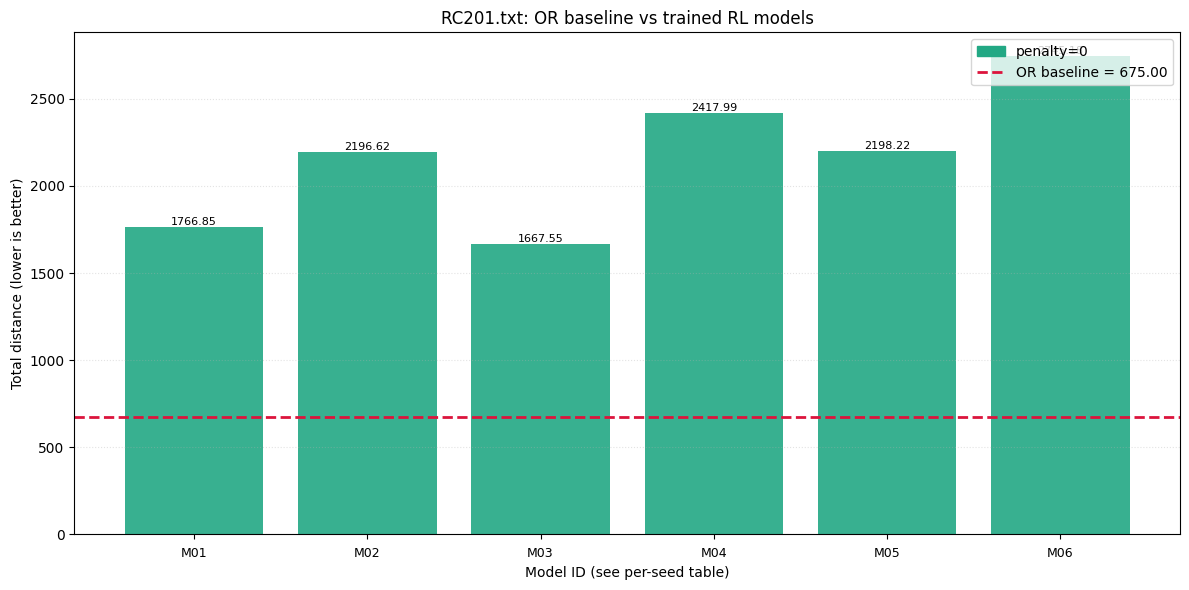


=== RC202.txt | OR baseline: 605.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC202.txt,RC1,0.0,0.0001,6238116,1754.334,189.97
1,M02,RC202.txt,RC1,0.0,0.0001,7454245,1287.367,112.79
2,M03,RC202.txt,RC1,0.0,0.0001,7960100,1519.577,151.17
3,M04,RC202.txt,RC1,0.0,0.0005,6238116,2378.586,293.15
4,M05,RC202.txt,RC1,0.0,0.0005,7454245,2043.947,237.84
5,M06,RC202.txt,RC1,0.0,0.0005,7960100,3028.828,400.63


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1287.367,1520.426,233.484,112.79,151.31
1,RC1,0.0,0.0005,3,2043.947,2483.787,500.798,237.84,310.54


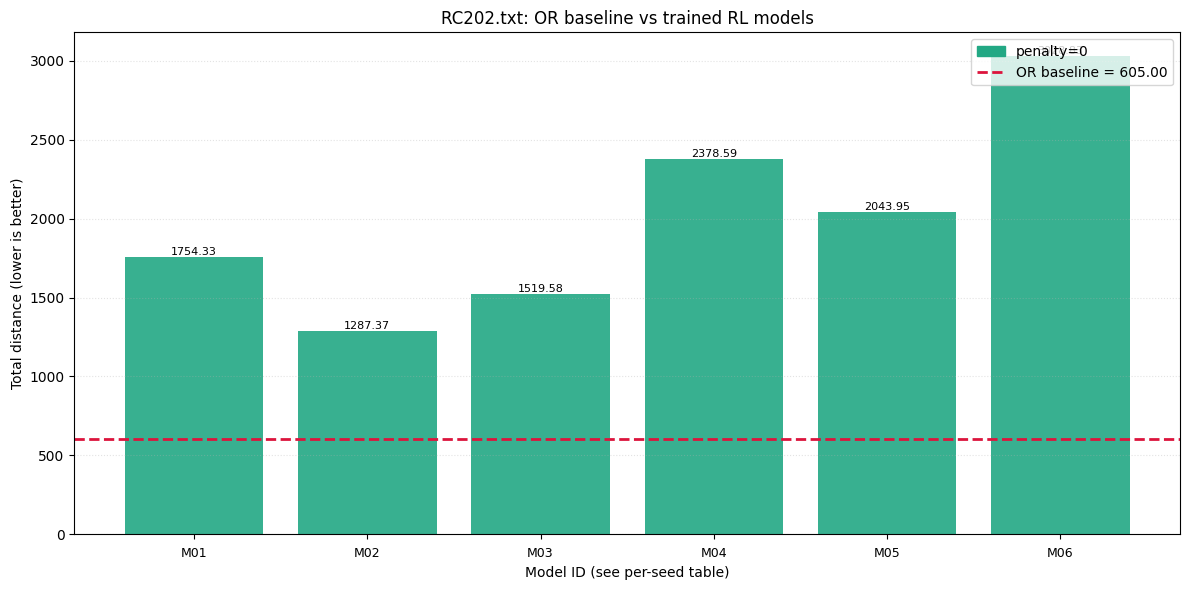


=== RC203.txt | OR baseline: 610.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC203.txt,RC1,0.0,0.0001,6238116,1984.641,225.35
1,M02,RC203.txt,RC1,0.0,0.0001,7454245,1108.990,81.80
2,M03,RC203.txt,RC1,0.0,0.0001,7960100,1675.645,174.70
3,M04,RC203.txt,RC1,0.0,0.0005,6238116,2297.924,276.71
4,M05,RC203.txt,RC1,0.0,0.0005,7454245,2029.691,232.74
5,M06,RC203.txt,RC1,0.0,0.0005,7960100,3424.495,461.39


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1108.990,1589.758,444.099,81.80,160.62
1,RC1,0.0,0.0005,3,2029.691,2584.036,740.111,232.74,323.61


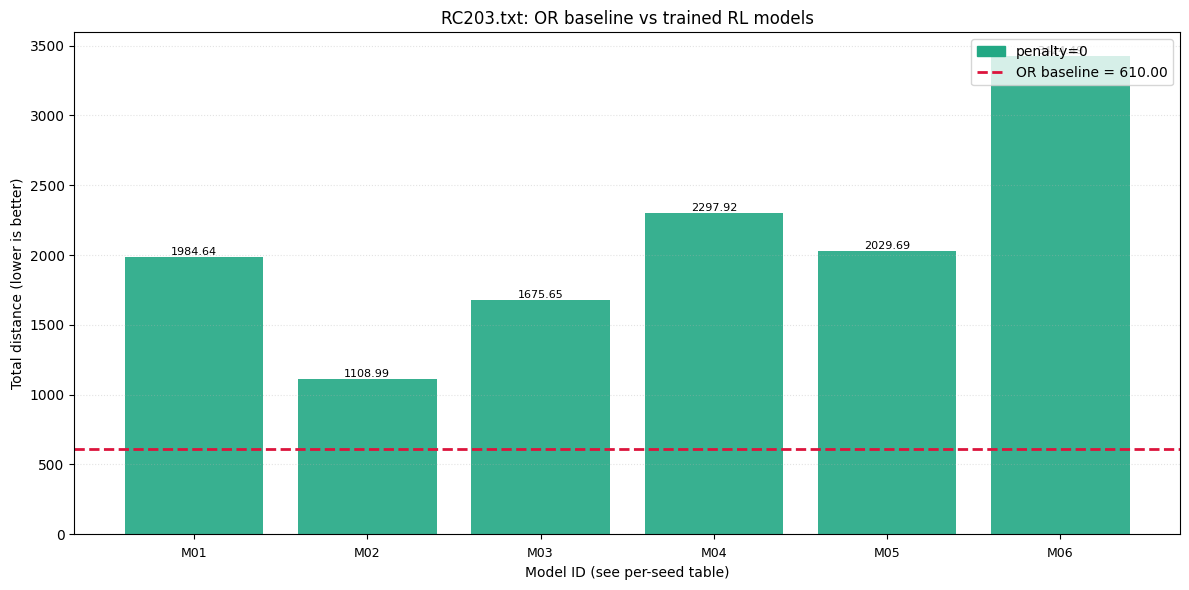


=== RC204.txt | OR baseline: 436.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC204.txt,RC1,0.0,0.0001,6238116,2184.470,401.03
1,M02,RC204.txt,RC1,0.0,0.0001,7454245,1007.117,130.99
2,M03,RC204.txt,RC1,0.0,0.0001,7960100,1815.691,316.44
3,M04,RC204.txt,RC1,0.0,0.0005,6238116,2202.128,405.08
4,M05,RC204.txt,RC1,0.0,0.0005,7454245,1930.303,342.73
5,M06,RC204.txt,RC1,0.0,0.0005,7960100,3578.156,720.68


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1007.117,1669.093,602.211,130.99,282.82
1,RC1,0.0,0.0005,3,1930.303,2570.196,883.437,342.73,489.49


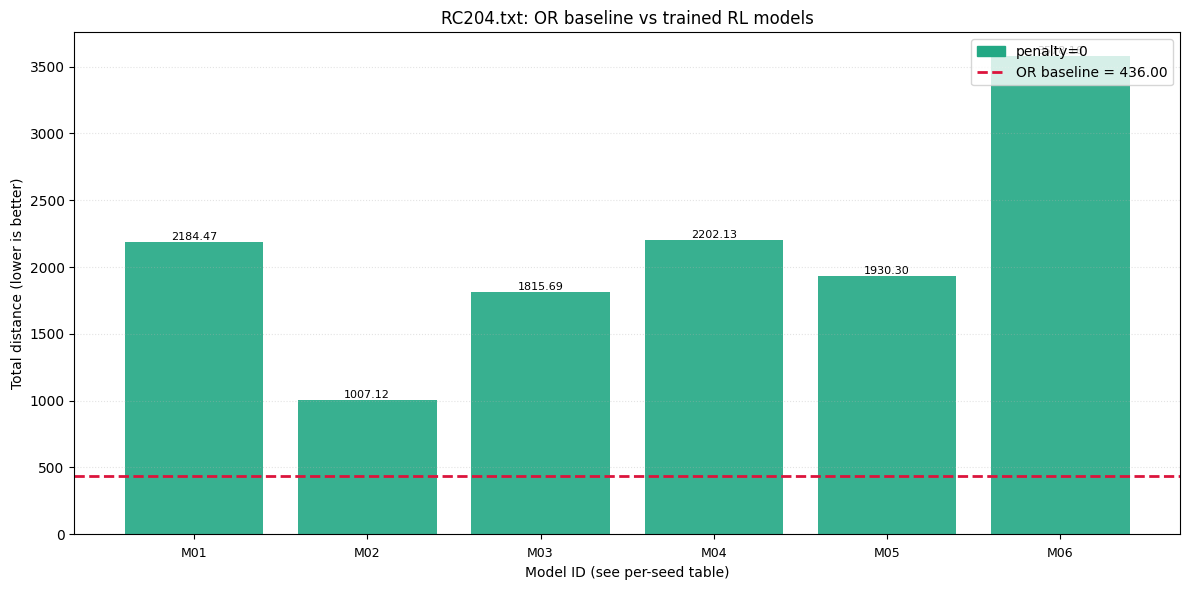


=== RC205.txt | OR baseline: 619.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC205.txt,RC1,0.0,0.0001,6238116,1686.064,172.39
1,M02,RC205.txt,RC1,0.0,0.0001,7454245,1842.868,197.72
2,M03,RC205.txt,RC1,0.0,0.0001,7960100,1564.163,152.69
3,M04,RC205.txt,RC1,0.0,0.0005,6238116,2300.033,271.57
4,M05,RC205.txt,RC1,0.0,0.0005,7454245,2312.475,273.58
5,M06,RC205.txt,RC1,0.0,0.0005,7960100,3151.697,409.16


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1564.163,1697.698,139.717,152.69,174.26
1,RC1,0.0,0.0005,3,2300.033,2588.068,488.157,271.57,318.10


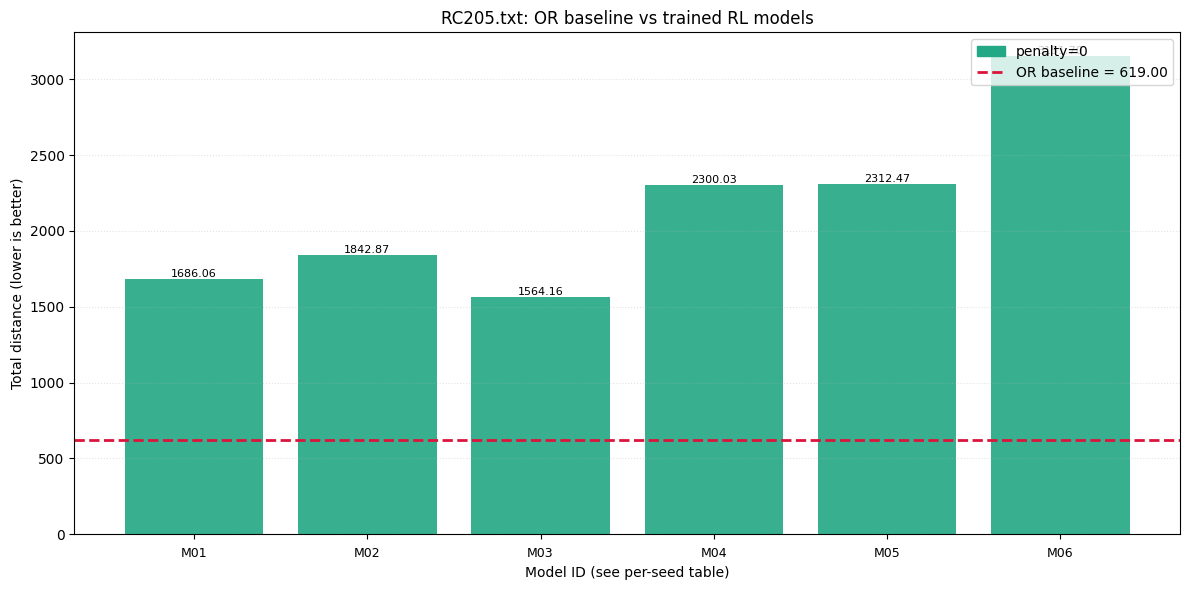


=== RC206.txt | OR baseline: 601.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC206.txt,RC1,0.0,0.0001,6238116,1663.370,176.77
1,M02,RC206.txt,RC1,0.0,0.0001,7454245,1988.702,230.90
2,M03,RC206.txt,RC1,0.0,0.0001,7960100,1627.905,170.87
3,M04,RC206.txt,RC1,0.0,0.0005,6238116,2309.467,284.27
4,M05,RC206.txt,RC1,0.0,0.0005,7454245,2272.454,278.11
5,M06,RC206.txt,RC1,0.0,0.0005,7960100,3180.641,429.22


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1627.905,1759.993,198.861,170.87,192.84
1,RC1,0.0,0.0005,3,2272.454,2587.521,513.991,278.11,330.54


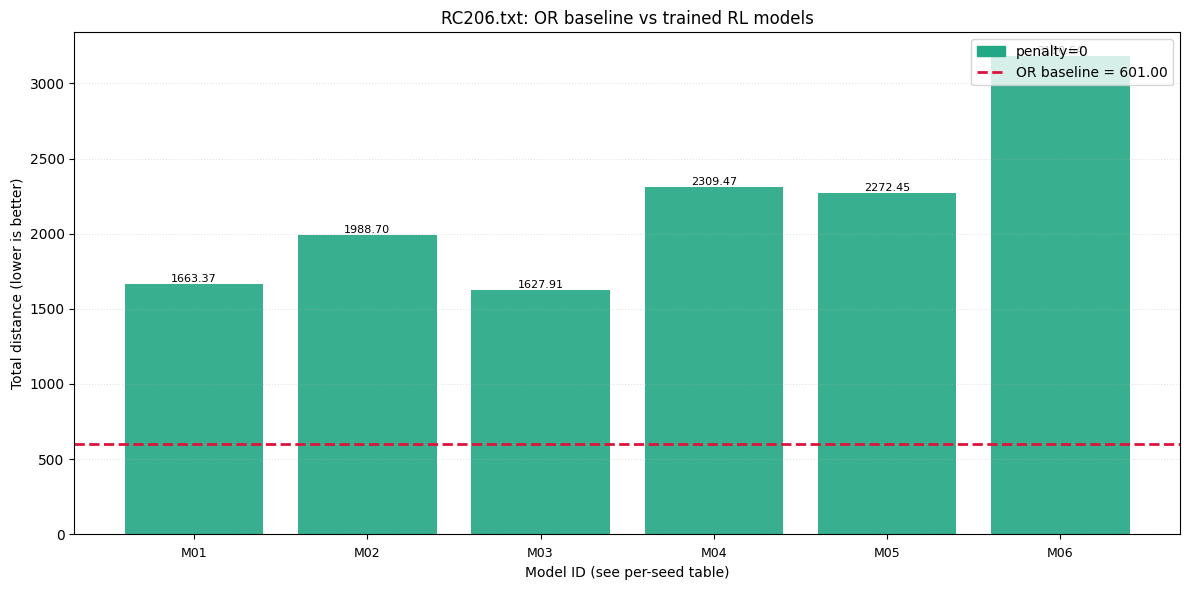


=== RC207.txt | OR baseline: 553.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC207.txt,RC1,0.0,0.0001,6238116,1511.900,173.40
1,M02,RC207.txt,RC1,0.0,0.0001,7454245,1231.652,122.72
2,M03,RC207.txt,RC1,0.0,0.0001,7960100,1648.544,198.11
3,M04,RC207.txt,RC1,0.0,0.0005,6238116,2225.465,302.43
4,M05,RC207.txt,RC1,0.0,0.0005,7454245,2075.604,275.34
5,M06,RC207.txt,RC1,0.0,0.0005,7960100,3694.940,568.16


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1231.652,1464.032,212.528,122.72,164.74
1,RC1,0.0,0.0005,3,2075.604,2665.336,894.806,275.34,381.98


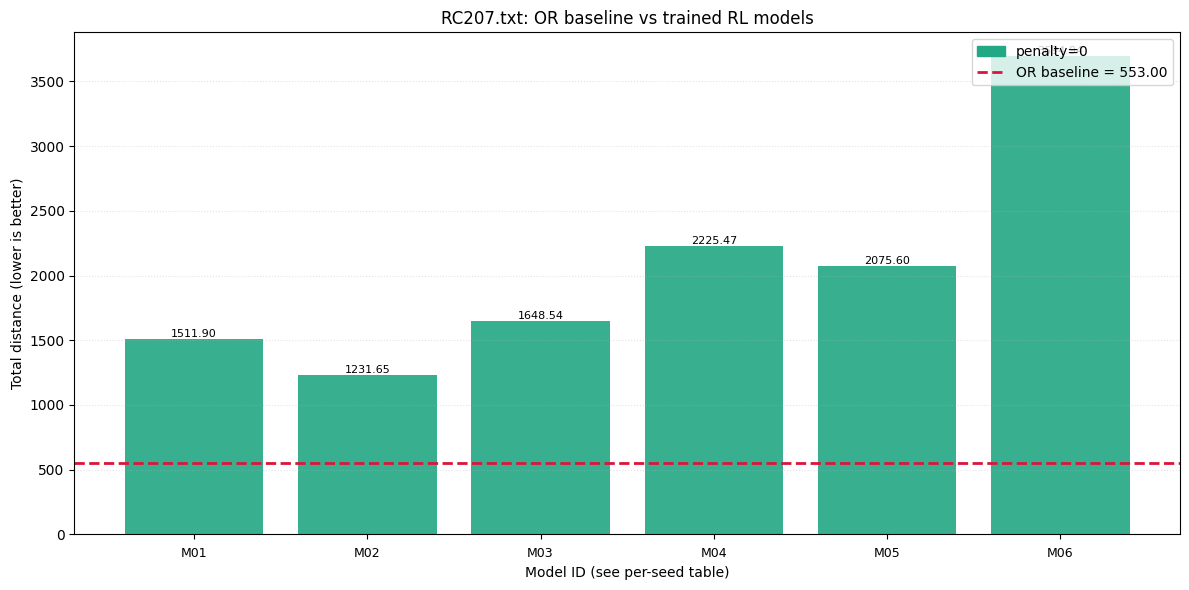


=== RC208.txt | OR baseline: 505.000 ===
Per-seed comparison (model_id matches x-axis):


,model_id,instance_id,family,penalty,learning_rate,seed,rl_distance,gap_vs_or_%
0,M01,RC208.txt,RC1,0.0,0.0001,6238116,1574.132,211.71
1,M02,RC208.txt,RC1,0.0,0.0001,7454245,1202.266,138.07
2,M03,RC208.txt,RC1,0.0,0.0001,7960100,1468.034,190.70
3,M04,RC208.txt,RC1,0.0,0.0005,6238116,2250.339,345.61
4,M05,RC208.txt,RC1,0.0,0.0005,7454245,2055.871,307.10
5,M06,RC208.txt,RC1,0.0,0.0005,7960100,3872.093,666.75


Aggregated by hyperparameters (across seeds):


,family,penalty,learning_rate,n_seeds,best_distance,mean_distance,std_distance,best_gap_vs_or_%,mean_gap_vs_or_%
0,RC1,0.0,0.0001,3,1202.266,1414.811,191.561,138.07,180.16
1,RC1,0.0,0.0005,3,2055.871,2726.101,997.210,307.10,439.82


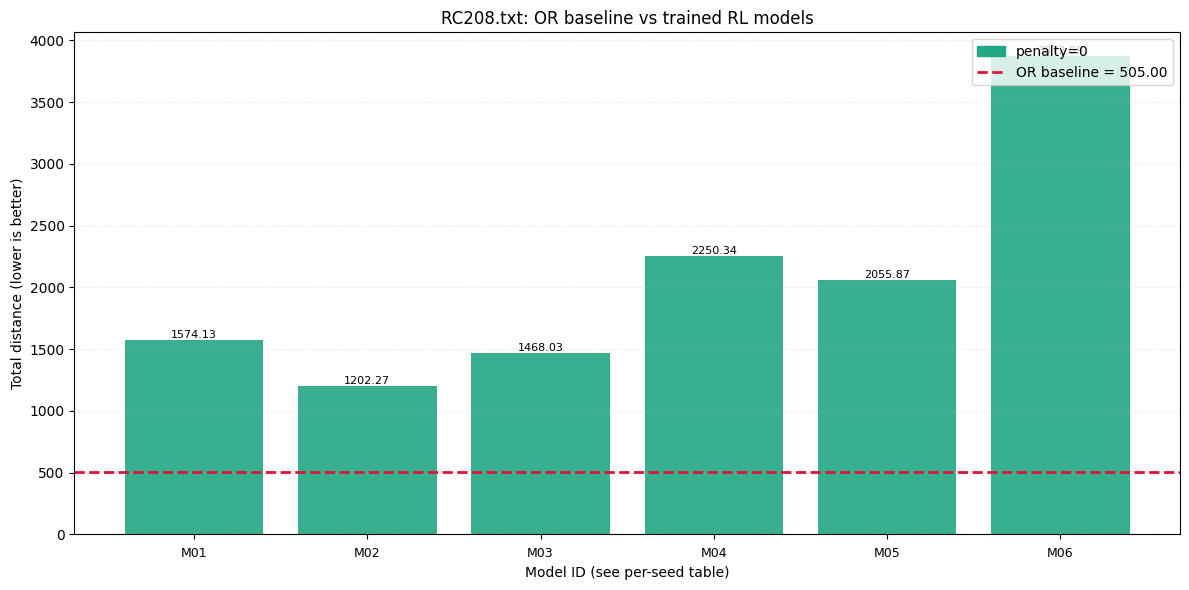

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from IPython.display import display

# Build a tidy table from rl_solutions
rows = []
for key, sol in rl_solutions.items():
    instance_id, file_name = key.split("_", 1)
    params = parse_file_name(file_name)
    rows.append({
        "instance_id": instance_id,
        "model_file": file_name,
        "rl_distance": sol.total_distance,
        "family": params["family"],
        "num_customers": params["num_customers"],
        "penalty": params["penalty"],
        "learning_rate": params["learning_rate"],
        "seed": params["seed"],
    })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("rl_solutions is empty. Run the inference cell first.")

instance_ids = sorted(df["instance_id"].unique())
n_instances = len(instance_ids)
print(f"Building {n_instances} plots and tables (one per instance)...")

global_penalties = sorted(df["penalty"].unique())
pen_norm = Normalize(vmin=min(global_penalties), vmax=max(global_penalties)) if len(global_penalties) > 1 else None
cmap = plt.colormaps["viridis"]

for instance_id in instance_ids:
    sub = df[df["instance_id"] == instance_id].copy()
    sub = sub.sort_values(["penalty", "learning_rate", "seed"]).reset_index(drop=True)

    or_baseline = or_solutions[instance_id].total_distance
    sub["gap_vs_or_%"] = (sub["rl_distance"] / or_baseline - 1.0) * 100.0

    # Short model IDs for readable x-axis
    sub["model_id"] = [f"M{i:02d}" for i in range(1, len(sub) + 1)]

    # ---- Table 1: direct comparison by hyperparameters and seed ----
    per_seed_table = sub[[
        "model_id", "instance_id", "family", "penalty", "learning_rate", "seed", "rl_distance", "gap_vs_or_%"
    ]].copy()
    per_seed_table["rl_distance"] = per_seed_table["rl_distance"].round(3)
    per_seed_table["gap_vs_or_%"] = per_seed_table["gap_vs_or_%"].round(2)

    print(f"\n=== {instance_id} | OR baseline: {or_baseline:.3f} ===")
    print("Per-seed comparison (model_id matches x-axis):")
    display(per_seed_table.reset_index(drop=True))

    # ---- Table 2: same model settings aggregated across seeds ----
    agg_table = (
        sub.groupby(["family", "penalty", "learning_rate"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            best_distance=("rl_distance", "min"),
            mean_distance=("rl_distance", "mean"),
            std_distance=("rl_distance", "std"),
        )
    )
    agg_table["best_gap_vs_or_%"] = (agg_table["best_distance"] / or_baseline - 1.0) * 100.0
    agg_table["mean_gap_vs_or_%"] = (agg_table["mean_distance"] / or_baseline - 1.0) * 100.0
    agg_table["best_distance"] = agg_table["best_distance"].round(3)
    agg_table["mean_distance"] = agg_table["mean_distance"].round(3)
    agg_table["std_distance"] = agg_table["std_distance"].fillna(0.0).round(3)
    agg_table["best_gap_vs_or_%"] = agg_table["best_gap_vs_or_%"].round(2)
    agg_table["mean_gap_vs_or_%"] = agg_table["mean_gap_vs_or_%"].round(2)
    agg_table = agg_table.sort_values(["penalty", "learning_rate"])

    print("Aggregated by hyperparameters (across seeds):")
    display(agg_table.reset_index(drop=True))

    # ---- Plot ----
    if pen_norm is None:
        colors = [cmap(0.6)] * len(sub)
    else:
        colors = [cmap(pen_norm(p)) for p in sub["penalty"]]

    fig_width = max(12, 0.55 * len(sub))
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    x = list(range(len(sub)))
    bars = ax.bar(x, sub["rl_distance"], color=colors, alpha=0.9)

    ax.axhline(or_baseline, color="crimson", linestyle="--", linewidth=2)

    for b, value in zip(bars, sub["rl_distance"]):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_title(f"{instance_id}: OR baseline vs trained RL models")
    ax.set_ylabel("Total distance (lower is better)")
    ax.set_xlabel("Model ID (see per-seed table)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model_id"], fontsize=9)
    ax.tick_params(axis="x", rotation=0, pad=6)
    ax.grid(axis="y", linestyle=":", alpha=0.35)

    penalty_handles = []
    for p in sorted(sub["penalty"].unique()):
        color = cmap(pen_norm(p)) if pen_norm is not None else cmap(0.6)
        penalty_handles.append(mpatches.Patch(color=color, label=f"penalty={p:g}"))

    or_handle = plt.Line2D([0], [0], color="crimson", linestyle="--", linewidth=2, label=f"OR baseline = {or_baseline:.2f}")
    ax.legend(handles=[*penalty_handles, or_handle], loc="upper right")

    fig.tight_layout()
    plt.show()

Seed sensitivity per fixed setting (instance + hyperparams):


,instance_id,family,penalty,learning_rate,n_seeds,min_distance,max_distance,spread,std_distance,cv_%
0,RC208.txt,RC1,0.0,0.0005,3,2055.871338,3872.093262,1816.221924,997.210026,36.580082
1,RC204.txt,RC1,0.0,0.0005,3,1930.302979,3578.156006,1647.853027,883.436528,34.372343
2,RC207.txt,RC1,0.0,0.0005,3,2075.603516,3694.940430,1619.336914,894.806153,33.571979
3,RC203.txt,RC1,0.0,0.0005,3,2029.690918,3424.494629,1394.803711,740.111259,28.641672
4,RC204.txt,RC1,0.0,0.0001,3,1007.117188,2184.469727,1177.352539,602.210937,36.080141
5,RC202.txt,RC1,0.0,0.0005,3,2043.947266,3028.828369,984.881104,500.797539,20.162659
6,RC206.txt,RC1,0.0,0.0005,3,2272.453613,3180.641357,908.187744,513.990866,19.864223
7,RC203.txt,RC1,0.0,0.0001,3,1108.989502,1984.640625,875.651123,444.098671,27.934978
8,RC205.txt,RC1,0.0,0.0005,3,2300.033203,3151.697266,851.664062,488.156589,18.861812
9,RC201.txt,RC1,0.0,0.0005,3,2198.218506,2745.180908,546.962402,275.233810,11.216656


Top 10 most seed-sensitive settings by spread:


,instance_id,family,penalty,learning_rate,spread,std_distance,cv_%
0,RC208.txt,RC1,0.0,0.0005,1816.221924,997.210026,36.580082
1,RC204.txt,RC1,0.0,0.0005,1647.853027,883.436528,34.372343
2,RC207.txt,RC1,0.0,0.0005,1619.336914,894.806153,33.571979
3,RC203.txt,RC1,0.0,0.0005,1394.803711,740.111259,28.641672
4,RC204.txt,RC1,0.0,0.0001,1177.352539,602.210937,36.080141
5,RC202.txt,RC1,0.0,0.0005,984.881104,500.797539,20.162659
6,RC206.txt,RC1,0.0,0.0005,908.187744,513.990866,19.864223
7,RC203.txt,RC1,0.0,0.0001,875.651123,444.098671,27.934978
8,RC205.txt,RC1,0.0,0.0005,851.664062,488.156589,18.861812
9,RC201.txt,RC1,0.0,0.0005,546.962402,275.233810,11.216656


Matched settings with all seeds present: 16
Per-seed summary across matched settings:


,seed,mean_distance,std_distance,mean_regret,std_regret
0,6238116,2031.730804,317.416024,306.534981,313.914016
1,7454245,1799.008820,458.918062,73.812996,163.450486
2,7960100,2478.946510,922.915856,753.750687,610.142512


How often each seed attains the best distance (ties included):


,seed,num_best,best_rate_%
0,7454245,12,75.00
1,7960100,3,18.75
2,6238116,1,6.25


Friedman test across seeds -> statistic=7.8750, p-value=0.0194969
Interpretation: reject equal-seed-performance hypothesis (seed-dependent behavior likely).


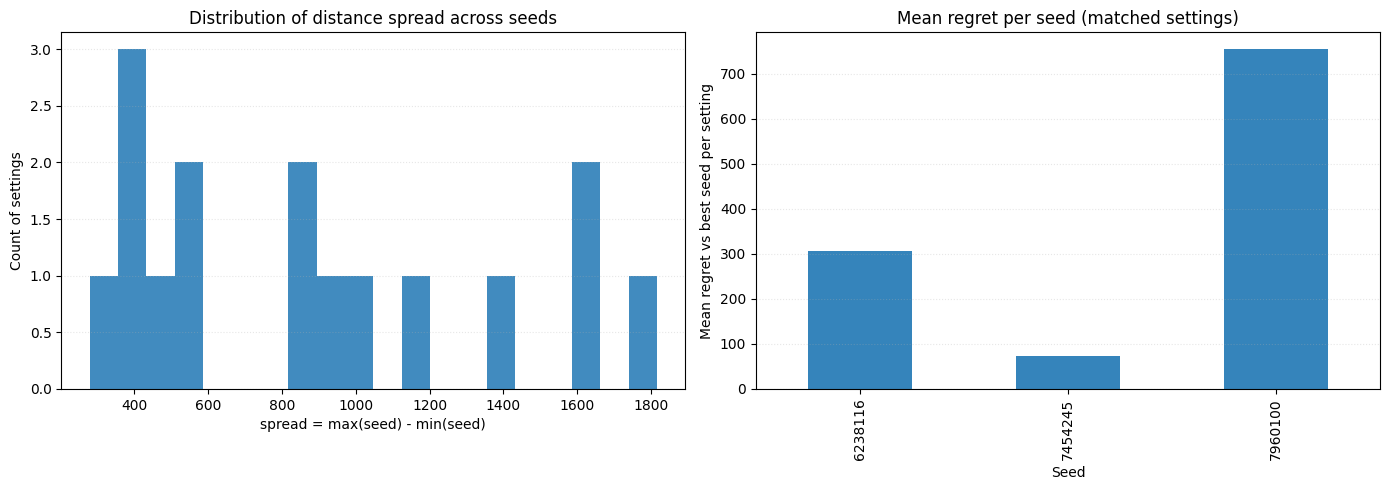

Average spread across settings: 890.450
Median spread across settings: 863.658


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from scipy.stats import friedmanchisquare
    _has_scipy = True
except Exception:
    _has_scipy = False

# ------------------------------------------------------------------
# Seed dependence analysis
# Uses df from Cell 5: columns include instance_id, penalty, learning_rate, seed, rl_distance
# ------------------------------------------------------------------
if "df" not in globals() or df.empty:
    raise ValueError("df is not available. Run Cell 5 first.")

seed_df = df.copy()
seed_df = seed_df.sort_values(["instance_id", "penalty", "learning_rate", "seed"]).reset_index(drop=True)
seed_df["setting_id"] = (
    seed_df["instance_id"].astype(str)
    + "|p=" + seed_df["penalty"].astype(str)
    + "|lr=" + seed_df["learning_rate"].astype(str)
    + "|fam=" + seed_df["family"].astype(str)
)

# Distance spread across seeds for each fixed model setting + instance
per_setting_spread = (
    seed_df.groupby(["instance_id", "family", "penalty", "learning_rate", "setting_id"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        min_distance=("rl_distance", "min"),
        max_distance=("rl_distance", "max"),
        mean_distance=("rl_distance", "mean"),
        std_distance=("rl_distance", "std"),
    )
)
per_setting_spread["std_distance"] = per_setting_spread["std_distance"].fillna(0.0)
per_setting_spread["spread"] = per_setting_spread["max_distance"] - per_setting_spread["min_distance"]
per_setting_spread["cv_%"] = np.where(
    per_setting_spread["mean_distance"] != 0,
    100.0 * per_setting_spread["std_distance"] / per_setting_spread["mean_distance"],
    np.nan,
)

print("Seed sensitivity per fixed setting (instance + hyperparams):")
display(
    per_setting_spread[[
        "instance_id", "family", "penalty", "learning_rate", "n_seeds", "min_distance", "max_distance", "spread", "std_distance", "cv_%"
    ]]
    .sort_values(["spread", "std_distance"], ascending=False)
    .reset_index(drop=True)
)

# Top unstable settings (largest spread)
top_unstable = per_setting_spread.sort_values("spread", ascending=False).head(10)
print("Top 10 most seed-sensitive settings by spread:")
display(
    top_unstable[[
        "instance_id", "family", "penalty", "learning_rate", "spread", "std_distance", "cv_%"
    ]].reset_index(drop=True)
)

# Build matched matrix (rows = identical settings, cols = seeds)
pivot = seed_df.pivot_table(
    index="setting_id",
    columns="seed",
    values="rl_distance",
    aggfunc="mean",
)

# keep only settings where all seeds are present
pivot_complete = pivot.dropna(axis=0, how="any")
print(f"Matched settings with all seeds present: {len(pivot_complete)}")

if len(pivot_complete) == 0:
    print("Not enough complete settings across seeds to test dependence.")
else:
    # Convert distances to regret per setting to compare fairly across instances/settings
    regrets = pivot_complete.sub(pivot_complete.min(axis=1), axis=0)

    # Aggregate by seed
    seed_summary = pd.DataFrame({
        "mean_distance": pivot_complete.mean(axis=0),
        "std_distance": pivot_complete.std(axis=0),
        "mean_regret": regrets.mean(axis=0),
        "std_regret": regrets.std(axis=0),
    }).sort_index()
    seed_summary.index.name = "seed"
    seed_summary = seed_summary.reset_index()

    print("Per-seed summary across matched settings:")
    display(seed_summary)

    # Win count: how often each seed is the best (including ties)
    is_best = pivot_complete.eq(pivot_complete.min(axis=1), axis=0)
    win_counts = is_best.sum(axis=0).rename("num_best").reset_index()
    win_counts.columns = ["seed", "num_best"]
    win_counts["best_rate_%"] = 100.0 * win_counts["num_best"] / len(pivot_complete)
    win_counts = win_counts.sort_values("num_best", ascending=False)

    print("How often each seed attains the best distance (ties included):")
    display(win_counts.reset_index(drop=True))

    # Statistical test: Friedman test on matched settings
    if _has_scipy and pivot_complete.shape[1] >= 2 and pivot_complete.shape[0] >= 2:
        seed_cols = list(pivot_complete.columns)
        stat, pvalue = friedmanchisquare(*[pivot_complete[c].values for c in seed_cols])
        print(f"Friedman test across seeds -> statistic={stat:.4f}, p-value={pvalue:.6g}")
        if pvalue < 0.05:
            print("Interpretation: reject equal-seed-performance hypothesis (seed-dependent behavior likely).")
        else:
            print("Interpretation: no significant seed effect detected at 5% level.")
    else:
        print("Friedman test skipped (scipy unavailable or insufficient matched data).")

    # ---------------- Visual diagnostics ----------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: spread distribution by setting
    axes[0].hist(per_setting_spread["spread"], bins=20, alpha=0.85)
    axes[0].set_title("Distribution of distance spread across seeds")
    axes[0].set_xlabel("spread = max(seed) - min(seed)")
    axes[0].set_ylabel("Count of settings")
    axes[0].grid(axis="y", linestyle=":", alpha=0.3)

    # Right: mean regret per seed (lower is better)
    regrets.mean(axis=0).sort_index().plot(kind="bar", ax=axes[1], alpha=0.9)
    axes[1].set_title("Mean regret per seed (matched settings)")
    axes[1].set_xlabel("Seed")
    axes[1].set_ylabel("Mean regret vs best seed per setting")
    axes[1].grid(axis="y", linestyle=":", alpha=0.3)

    fig.tight_layout()
    plt.show()

    # Optional compact indicator for quick read
    mean_spread = per_setting_spread["spread"].mean()
    median_spread = per_setting_spread["spread"].median()
    print(f"Average spread across settings: {mean_spread:.3f}")
    print(f"Median spread across settings: {median_spread:.3f}")